#### Import

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#### Obtaining Training Data

In [12]:
df = pd.read_csv('../data/cleaned_movie_ratings.csv')
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

# Encode IDs
df['user_encoded'] = user_enc.fit_transform(df['userId'])
df['movie_encoded'] = movie_enc.fit_transform(df['movieId'])

# Process genres
genre_dummies = df['genres'].str.get_dummies(sep='|')
df = df.join(genre_dummies)

genre_columns = genre_dummies.columns.tolist()
num_genres = len(genre_columns)

num_users = df['user_encoded'].nunique()
num_movies = df['movie_encoded'].nunique()

print(f"Total separate genres found: {num_genres}")

print(f"Total Unique Users: {num_users}, Total Unique Movies: {num_movies}")

Total separate genres found: 19
Total Unique Users: 606, Total Unique Movies: 2272


In [13]:
# Stratified split ensures every user appears in both train and test
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['user_encoded'])

In [14]:
# Fit scaler ONLY on train, but transform BOTH
scaler = MinMaxScaler()
train = train.copy()
test = test.copy()

train['year_scaled'] = scaler.fit_transform(train[['year']])
test['year_scaled'] = scaler.transform(test[['year']])

print(f"Training data: {len(train)} ratings")
print(f"Testing data: {len(test)} ratings")

Training data: 64860 ratings
Testing data: 16215 ratings


#### Prepare Input Arrays

In [15]:
# Extract numpy arrays that Keras needs as inputs
# Each input corresponds to one Input() layer in our model

train_user = train['user_encoded'].values
train_movie = train['movie_encoded'].values
train_genre = train[genre_columns].values.astype('float32')
train_year = train['year_scaled'].values.astype('float32')
y_train = train['rating'].values.astype('float32')

test_user = test['user_encoded'].values
test_movie = test['movie_encoded'].values
test_genre = test[genre_columns].values.astype('float32')
test_year = test['year_scaled'].values.astype('float32')
y_test = test['rating'].values.astype('float32')

print(f"Train inputs: {len(y_train)} samples")
print(f"Test inputs: {len(y_test)} samples")
print(f"Genre features shape: {train_genre.shape}")
print(f"Rating range: {y_train.min():.1f} to {y_train.max():.1f}")


Train inputs: 64860 samples
Test inputs: 16215 samples
Genre features shape: (64860, 19)
Rating range: 0.5 to 5.0


#### Building the Neural Network

In [16]:
embedding_dim = 64  # Size of the learned "taste profile" for each user/movie

In [17]:
# --- Collaborative Filtering Branch ---

# User embedding: converts user ID → 64-dimensional vector
user_input = Input(shape=(1,), name='user_input')
user_embedding = Embedding(num_users, embedding_dim, name='user_embedding')(user_input)
user_flat = Flatten()(user_embedding)

# Movie embedding: converts movie ID → 64-dimensional vector
movie_input = Input(shape=(1,), name='movie_input')
movie_embedding = Embedding(num_movies, embedding_dim, name='movie_embedding')(movie_input)
movie_flat = Flatten()(movie_embedding)

In [18]:
# --- Content-Based Branch ---

# Genre input: 19 binary features (one-hot encoded)
genre_input = Input(shape=(num_genres,), name='genre_input')
genre_dense = Dense(32, activation='relu')(genre_input)

# Year input: 1 scaled feature
year_input = Input(shape=(1,), name='year_input')

In [19]:
# --- Merge Both Branches ---

# Concatenate: stacks all features into one vector (64+64+32+1 = 161 values)
concat = Concatenate()([user_flat, movie_flat, genre_dense, year_input])

In [20]:
# --- Deep Layers ---

x = Dense(128, activation='relu')(concat)
x = Dropout(0.3)(x)       # Randomly disable 30% of neurons to prevent overfitting
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)       # 20% dropout (less aggressive in smaller layers)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='linear', name='output')(x)  # Predict a single rating value

In [23]:
# --- Compile ---

model = Model(inputs=[user_input, movie_input, genre_input, year_input], outputs=output)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',    # Mean Squared Error — standard for regression
    metrics=['mae'] # Mean Absolute Error — easier to interpret
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 64)     │     38,784 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 64)     │    145,408 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genre_input         │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 64)        │          0 │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        640 │ genre_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ year_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 161)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ dense[0][0],      │
│                     │                   │            │ year_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     20,736 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 215,937 (843.50 KB)

 Trainable params: 215,937 (843.50 KB)

 Non-trainable params: 0 (0.00 B)

#### Training the Model

In [22]:
# EarlyStopping: stops training if validation loss doesn't improve for 5 epochs
# ReduceLROnPlateau: halves learning rate if val_loss stalls for 3 epochs

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
history = model.fit(
    [train_user, train_movie, train_genre, train_year],  # 4 inputs
    y_train,                                              # target ratings
    validation_data=([test_user, test_movie, test_genre, test_year], y_test),
    epochs=50,          # Max epochs (EarlyStopping will likely stop earlier)
    batch_size=256,     # Process 256 ratings at a time
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.7394 - mae: 0.9774 - val_loss: 0.7710 - val_mae: 0.6888 - learning_rate: 0.0010
Epoch 2/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8383 - mae: 0.7144 - val_loss: 0.8115 - val_mae: 0.7228 - learning_rate: 0.0010
Epoch 3/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7855 - mae: 0.6904 - val_loss: 0.7431 - val_mae: 0.6789 - learning_rate: 0.0010
Epoch 4/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7436 - mae: 0.6709 - val_loss: 0.7336 - val_mae: 0.6770 - learning_rate: 0.0010
Epoch 5/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7020 - mae: 0.6481 - val_loss: 0.7865 - val_mae: 0.7149 - learning_rate: 0.0010
Epoch 6/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6701 - mae: 0.6331 - val_loss: 0.7352 - val_mae: 0.6822 - learning_rate: 0.0010
Epoch 7/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6441 - mae: 0.6201 - val_loss: 0.7241 - val_mae: 0.6744 - learning_rate: 0.0010
Epoch 

#### Evaluate and Visualise

507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6938 - mae: 0.6493

Test MSE:  0.6938
Test RMSE: 0.8329
Test MAE:  0.6493
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Sample predictions (clipped) vs actual:
  Predicted: 3.66  |  Actual: 4.0
  Predicted: 4.54  |  Actual: 5.0
  Predicted: 3.32  |  Actual: 4.0
  Predicted: 2.75  |  Actual: 4.5
  Predicted: 2.41  |  Actual: 1.0
  Predicted: 2.79  |  Actual: 3.0
  Predicted: 4.01  |  Actual: 5.0
  Predicted: 3.68  |  Actual: 5.0
  Predicted: 4.30  |  Actual: 4.0
  Predicted: 3.85  |  Actual: 4.5


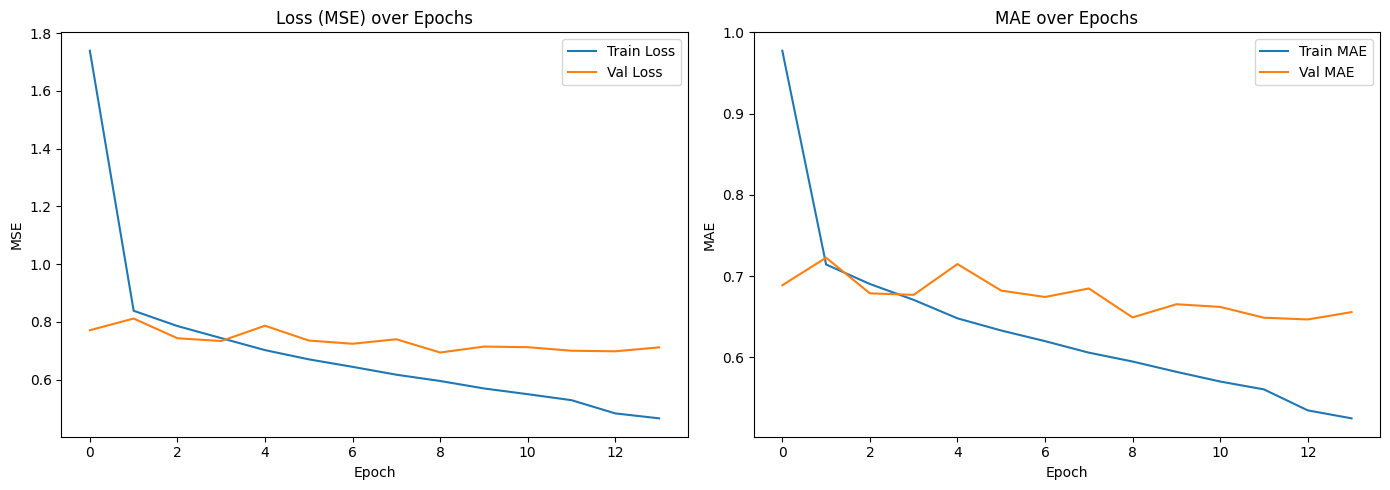

In [24]:
# Evaluate on test set
loss, mae = model.evaluate([test_user, test_movie, test_genre, test_year], y_test)
print(f"\nTest MSE:  {loss:.4f}")
print(f"Test RMSE: {loss**0.5:.4f}")
print(f"Test MAE:  {mae:.4f}")

# Get predictions with clipping to valid rating range [0.5, 5.0]
predictions = model.predict([test_user, test_movie, test_genre, test_year])
predictions_clipped = np.clip(predictions, 0.5, 5.0)

# Show a few example predictions vs actual
print("\nSample predictions (clipped) vs actual:")
for i in range(10):
    print(f"  Predicted: {predictions_clipped[i][0]:.2f}  |  Actual: {y_test[i]:.1f}")
    
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss (MSE) over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE')
ax1.legend()
ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Val MAE')
ax2.set_title('MAE over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
plt.tight_layout()
plt.show()

#### New User Recommendations

Our model uses learned embeddings, so a new user has no embedding.
Approach: Use the average user embedding + filter by genre preferences.

In [25]:
# Define the new user's genre preferences (0-5 scale)
genre_preferences = {
    'Action': 0.0,
    'Adventure': 5.0,
    'Animation': 0.0,
    'Children': 0.0,
    'Comedy': 0.0,
    'Crime': 0.0,
    'Documentary': 0.0,
    'Drama': 0.0,
    'Fantasy': 5.0,
    'Film-Noir': 0.0,
    'Horror': 0.0,
    'IMAX': 0.0,
    'Musical': 0.0,
    'Mystery': 0.0,
    'Romance': 0.0,
    'Sci-Fi': 0.0,
    'Thriller': 0.0,
    'War': 0.0,
    'Western': 0.0,
}

In [26]:
# Get the average user embedding (represents a "generic" user)
# The embedding layer is a weight matrix of shape (num_users, 64)
user_embedding_weights = model.get_layer('user_embedding').get_weights()[0]
avg_user_embedding = user_embedding_weights.mean(axis=0)  # Average across all users

# Get unique movies with their features
movies_df = df.drop_duplicates(subset='movie_encoded').copy()
movies_df = movies_df.sort_values('movie_encoded').reset_index(drop=True)
all_movie_ids = movies_df['movie_encoded'].values
all_movie_genres = movies_df[genre_columns].values.astype('float32')

# Scale year for all movies
all_movie_years = scaler.transform(movies_df[['year']]).astype('float32').flatten()




Predict ratings using the average user embedding.
We need to bypass the embedding lookup and feed the avg embedding directly.
Easiest approach: find the existing user closest to the average embedding, then use their ID for predictions.

In [27]:
from scipy.spatial.distance import cdist
distances = cdist([avg_user_embedding], user_embedding_weights, metric='cosine')[0]
closest_user_encoded = np.argmin(distances)

# Create input arrays
n_movies = len(all_movie_ids)
user_array = np.full(n_movies, closest_user_encoded)

# Predict
predicted_ratings = model.predict(
    [user_array, all_movie_ids, all_movie_genres, all_movie_years],
    verbose=0
).flatten()
predicted_ratings = np.clip(predicted_ratings, 0.5, 5.0)

# Step 5: Score movies based on genre preference match
# Calculate how well each movie matches the new user's preferred genres
pref_vector = np.array([genre_preferences.get(g, 0.0) for g in genre_columns])
pref_vector = pref_vector / (pref_vector.max() + 1e-8)  # Normalize to 0-1
genre_match_scores = all_movie_genres @ pref_vector  # Dot product with preferences

# Combine: predicted rating (model quality) + genre match (user taste)
# Weight: 60% model prediction, 40% genre preference match
combined_scores = 0.6 * (predicted_ratings / 5.0) + 0.4 * (genre_match_scores / genre_match_scores.max())

# Step 6: Show top recommendations
movies_df = movies_df.copy()
movies_df['predicted_rating'] = predicted_ratings
movies_df['genre_match'] = genre_match_scores
movies_df['combined_score'] = combined_scores
top_movies = movies_df.nlargest(15, 'combined_score')
print("=" * 70)
print("TOP 15 RECOMMENDATIONS FOR NEW USER")
print(f"Preferences: {[g for g, v in genre_preferences.items() if v > 0]}")
print("=" * 70)
for i, (_, row) in enumerate(top_movies.iterrows(), 1):
    print(f"{i:2d}. {row['clean_title']} ({int(row['year'])})")
    print(f"    Genres: {row['genres']}")
    print(f"    Predicted Rating: {row['predicted_rating']:.2f}  |  Genre Match: {row['genre_match']:.2f}")
    print()

TOP 15 RECOMMENDATIONS FOR NEW USER
Preferences: ['Adventure', 'Fantasy']
 1. Princess Bride, The (1987)
    Genres: Action|Adventure|Comedy|Fantasy|Romance
    Predicted Rating: 4.72  |  Genre Match: 2.00

 2. Lord of the Rings: The Return of the King, The (2003)
    Genres: Action|Adventure|Drama|Fantasy
    Predicted Rating: 4.66  |  Genre Match: 2.00

 3. Toy Story 3 (2010)
    Genres: Adventure|Animation|Children|Comedy|Fantasy|IMAX
    Predicted Rating: 4.64  |  Genre Match: 2.00

 4. Spirited Away (Sen to Chihiro no kamikakushi) (2001)
    Genres: Adventure|Animation|Fantasy
    Predicted Rating: 4.62  |  Genre Match: 2.00

 5. Lord of the Rings: The Two Towers, The (2002)
    Genres: Adventure|Fantasy
    Predicted Rating: 4.59  |  Genre Match: 2.00

 6. Harry Potter and the Deathly Hallows: Part 1 (2010)
    Genres: Action|Adventure|Fantasy|IMAX
    Predicted Rating: 4.58  |  Genre Match: 2.00

 7. Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986)
    Genres: Action|Ad

#### Recommendations for an Existing User

Pick a user from the dataset, predict ratings for unseen movies, and compare predicted vs actual for movies they DID rate.

In [28]:
# Pick a user
target_user_id = 1

# Get this user's data
user_data = df[df['userId'] == target_user_id]
target_user_encoded = user_data['user_encoded'].iloc[0]

# Movies this user HAS rated
rated_movie_ids = set(user_data['movie_encoded'].values)
print(f"User {target_user_id} has rated {len(rated_movie_ids)} movies\n")

User 1 has rated 211 movies



Compare predicted vs actual for rated movies

In [29]:

print("=" * 70)
print("PREDICTED vs ACTUAL RATINGS (movies this user already rated)")
print("=" * 70)
sample = user_data.sample(min(10, len(user_data)), random_state=42)
sample_user = sample['user_encoded'].values
sample_movie = sample['movie_encoded'].values
sample_genre = sample[genre_columns].values.astype('float32')
sample_year = scaler.transform(sample[['year']]).astype('float32').flatten()
sample_actual = sample['rating'].values
sample_preds = model.predict(
    [sample_user, sample_movie, sample_genre, sample_year],
    verbose=0
).flatten()
sample_preds = np.clip(sample_preds, 0.5, 5.0)
for i in range(len(sample)):
    title = sample.iloc[i]['clean_title']
    print(f"  {title}: Predicted={sample_preds[i]:.2f}  Actual={sample_actual[i]:.1f}  "
          f"(off by {abs(sample_preds[i] - sample_actual[i]):.2f})")

PREDICTED vs ACTUAL RATINGS (movies this user already rated)
  Three Musketeers, The: Predicted=3.72  Actual=4.0  (off by 0.28)
  Fight Club: Predicted=4.38  Actual=5.0  (off by 0.62)
  Young Sherlock Holmes: Predicted=3.56  Actual=3.0  (off by 0.56)
  Terminator, The: Predicted=4.11  Actual=5.0  (off by 0.89)
  E.T. the Extra-Terrestrial: Predicted=4.26  Actual=5.0  (off by 0.74)
  X-Men: Predicted=4.04  Actual=5.0  (off by 0.96)
  Mr. Smith Goes to Washington: Predicted=4.66  Actual=5.0  (off by 0.34)
  Longest Day, The: Predicted=4.36  Actual=4.0  (off by 0.36)
  Canadian Bacon: Predicted=3.90  Actual=5.0  (off by 1.10)
  Big Lebowski, The: Predicted=4.14  Actual=5.0  (off by 0.86)


Recommend unseen movies

In [30]:
print("\n" + "=" * 70)
print(f"TOP 15 RECOMMENDED UNSEEN MOVIES FOR USER {target_user_id}")
print("=" * 70)

# Get all movies this user HASN'T rated
unseen = movies_df[~movies_df['movie_encoded'].isin(rated_movie_ids)].copy()
n_unseen = len(unseen)
unseen_user = np.full(n_unseen, target_user_encoded)
unseen_movie = unseen['movie_encoded'].values
unseen_genre = unseen[genre_columns].values.astype('float32')
unseen_year = scaler.transform(unseen[['year']]).astype('float32').flatten()
unseen_preds = model.predict(
    [unseen_user, unseen_movie, unseen_genre, unseen_year],
    verbose=0
).flatten()
unseen_preds = np.clip(unseen_preds, 0.5, 5.0)
unseen = unseen.copy()
unseen['predicted_rating'] = unseen_preds
top_unseen = unseen.nlargest(15, 'predicted_rating')
for i, (_, row) in enumerate(top_unseen.iterrows(), 1):
    print(f"{i:2d}. {row['clean_title']} ({int(row['year'])})")
    print(f"    Genres: {row['genres']}")
    print(f"    Predicted Rating: {row['predicted_rating']:.2f}")
    print()


TOP 15 RECOMMENDED UNSEEN MOVIES FOR USER 1
 1. It Happened One Night (1934)
    Genres: Comedy|Romance
    Predicted Rating: 5.00

 2. Streetcar Named Desire, A (1951)
    Genres: Drama
    Predicted Rating: 5.00

 3. Grand Day Out with Wallace and Gromit, A (1989)
    Genres: Adventure|Animation|Children|Comedy|Sci-Fi
    Predicted Rating: 5.00

 4. Bridge on the River Kwai, The (1957)
    Genres: Adventure|Drama|War
    Predicted Rating: 5.00

 5. Big Sleep, The (1946)
    Genres: Crime|Film-Noir|Mystery
    Predicted Rating: 4.97

 6. His Girl Friday (1940)
    Genres: Comedy|Romance
    Predicted Rating: 4.96

 7. Ben-Hur (1959)
    Genres: Action|Adventure|Drama
    Predicted Rating: 4.89

 8. 12 Angry Men (1957)
    Genres: Drama
    Predicted Rating: 4.88

 9. Paths of Glory (1957)
    Genres: Drama|War
    Predicted Rating: 4.88

10. All About Eve (1950)
    Genres: Drama
    Predicted Rating: 4.87

11. City Lights (1931)
    Genres: Comedy|Drama|Romance
    Predicted Rating:

#### Export the model

In [31]:
import pickle

# Save the trained model
model.save('../src/hybrid_model.keras')

# Save the encoders (to translate real IDs ↔ encoded IDs)
with open('../src/encoders.pkl', 'wb') as f:
    pickle.dump({
        'user_encoder': user_enc,
        'movie_encoder': movie_enc,
        'genre_columns': genre_columns,
        'year_scaler': scaler,
    }, f)

# Save the movie catalog (for displaying titles, genres in the app)
movies_catalog = df.drop_duplicates(subset='movie_encoded')[
    ['movieId', 'movie_encoded', 'genres', 'year', 'clean_title']
].sort_values('movie_encoded').reset_index(drop=True)
movies_catalog.to_csv('../src/movies_catalog.csv', index=False)

print("Saved: model, encoders, and movie catalog")

Saved: model, encoders, and movie catalog
